In [ ]:
from flower_model._clustering import _spherical_kmeans
from flower_model.external._gabor_like_filters import _gabor_like_filters
from flower_model._filterbank import _shift_filters
import torch
import matplotlib.pyplot as plt
import math
import numpy as np

In [22]:
N = 63
sigma = 50.
k = 2500
steps = 16
SPH_KMEANS_ITERS = 100
device='cuda'

In [23]:
filters, r = _gabor_like_filters(N, sigma, 8, .7)
print(filters.shape)

(217, 63, 63)


In [24]:
filters = filters.astype("complex64")
filters = torch.tensor(filters, device=device)
filters = torch.abs(filters)

In [25]:
filters, _ = _shift_filters(filters, steps, N+1)
shift_dim = filters.size(dim=1)

print(filters.shape)

torch.Size([222208, 94, 94])


In [26]:
filter_amount = filters.size(dim=0)
filters = filters.view(filter_amount, -1)

In [27]:
labels = _spherical_kmeans(k, filters, SPH_KMEANS_ITERS)

In [28]:
centroid_list = []
for cluster in range(k):
    filters_in_cluster = filters[labels == cluster].abs()
    centroid_list.append(torch.mean(filters_in_cluster, dim=0))
centroids = torch.stack(centroid_list)
print(centroids.shape)
centroids = centroids.view(k, -1)

torch.Size([2500, 8836])


torch.Size([82, 8836])


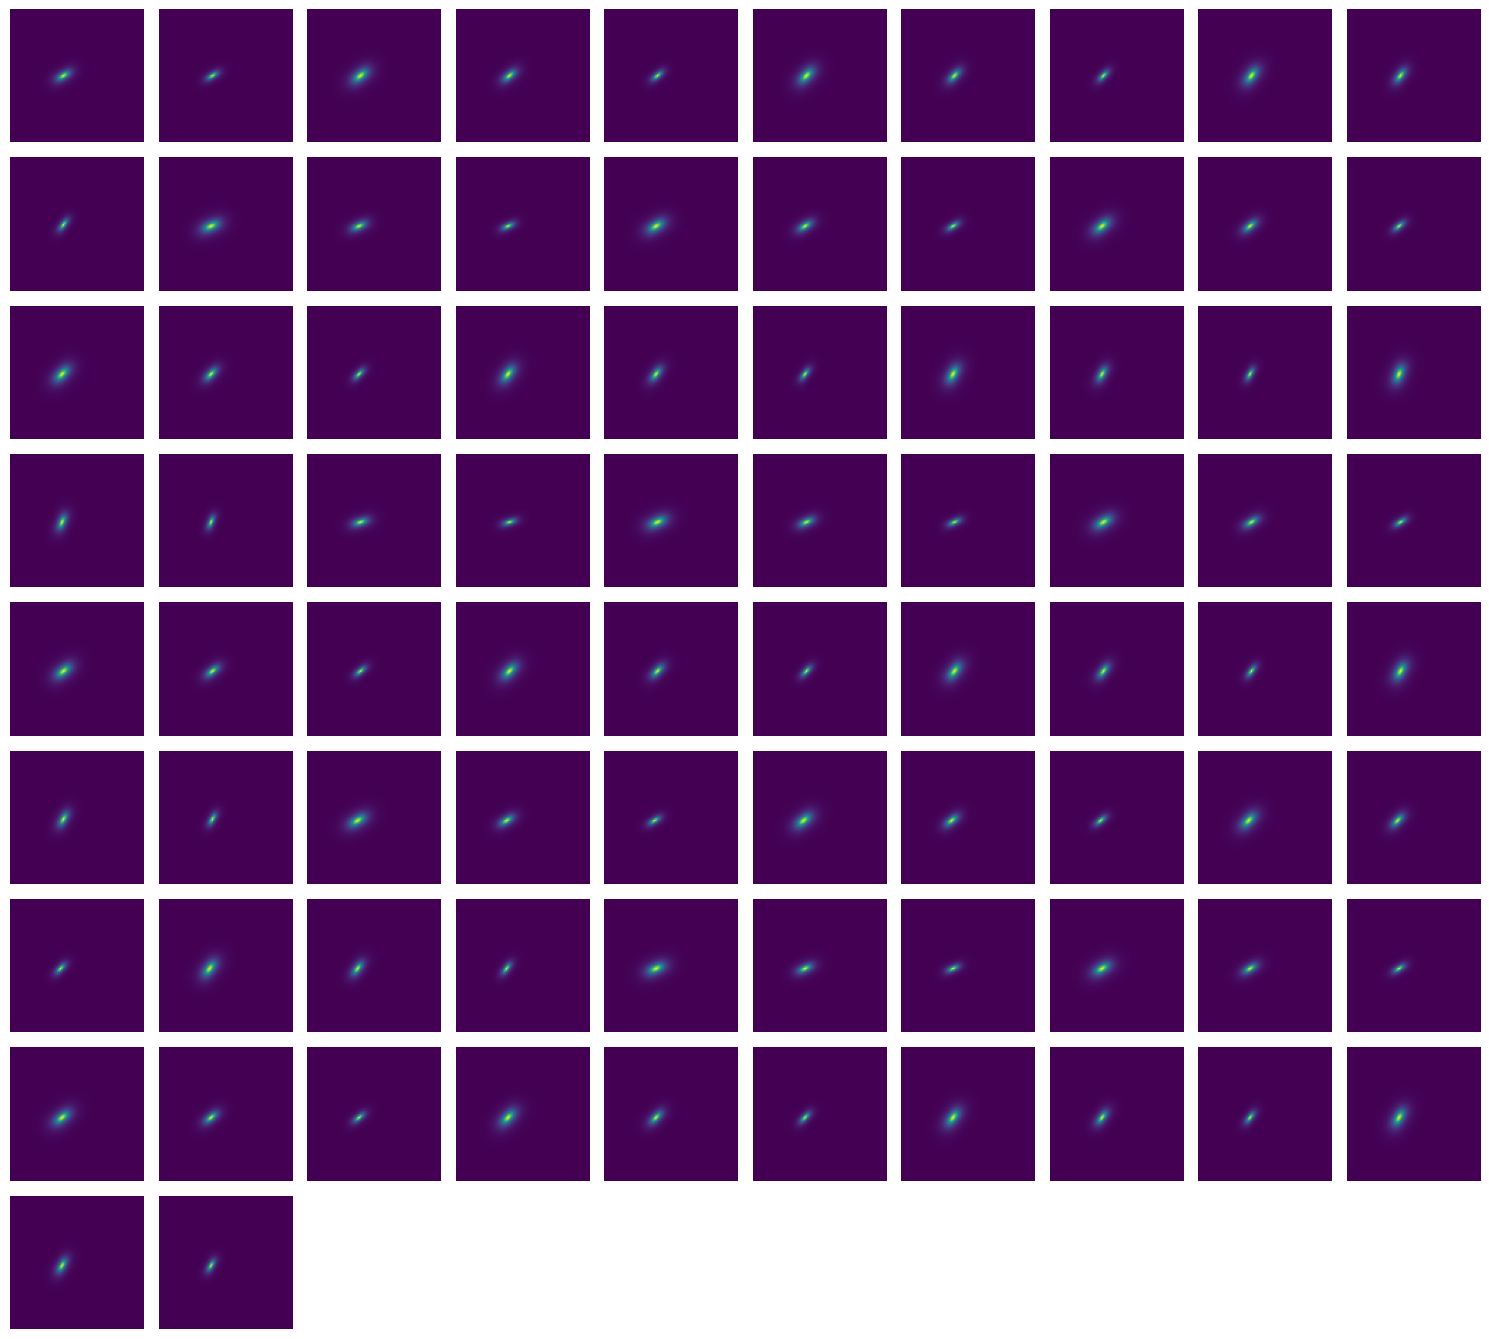

torch.Size([94, 94])


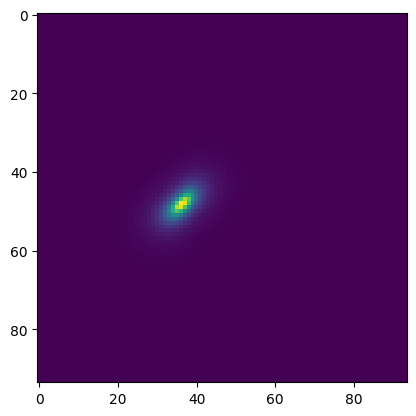

In [29]:
filters_in_cluster = filters[labels == 6].abs().view(-1, shift_dim*shift_dim)

f = filters_in_cluster.squeeze(0).cpu()        # shape [N, 1024]
print(f.shape)
n = f.shape[0]
size = int(math.sqrt(f.shape[1]))
assert size * size == f.shape[1], "expected square (H*W)"

cols = int(math.ceil(math.sqrt(n)))
rows = int(math.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
axes = np.atleast_1d(axes).flatten()

for i in range(rows * cols):
    ax = axes[i]
    if i < n:
        img = f[i].reshape(size, size).numpy()
        ax.imshow(img, cmap="viridis")
    ax.axis("off")

plt.tight_layout()
plt.show()

centroid = torch.mean(filters_in_cluster, dim=0).view(shift_dim, shift_dim).cpu()
print(centroid.shape)
plt.imshow(centroid, cmap='viridis')
plt.show()

In [30]:
# f = centroids.squeeze(0).cpu()        # shape [N, 1024]
# print(f.shape)
# n = f.shape[0]
# size = int(math.sqrt(f.shape[1]))
# assert size * size == f.shape[1], "expected square (H*W)"

# cols = int(math.ceil(math.sqrt(n)))
# rows = int(math.ceil(n / cols))

# fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
# axes = np.atleast_1d(axes).flatten()

# for i in range(rows * cols):
#     ax = axes[i]
#     if i < n:
#         img = f[i].reshape(size, size).numpy()
#         ax.imshow(img, cmap="viridis")
#     ax.axis("off")

# plt.tight_layout()
# plt.show()